#I S S U E


The v10 model achieved the first best val accuracy of 75.59% but peaked early in epoch 2. Subsequent versions have not performed as well and have triggered early stop before getting to epoch8, suggesting the model never gets enough time to refine at a lower learning rate.

The trainVal gap was initially thought to be due to overfitting, but attempted fixes (oversampling, frame weighting, frame count capping) have failed to make any improvement in accuracy and overfitting.

The suspicion is that this issue is related to the lr=0.001 with Adam causing fast coarse convergence but preventing fine boundary refinement.  The scheduler (patience=2) and earlystop (patience=3) cut trainingshort before the reduced learning rate can take effect.

in v14, we started with the v10 notebook (best perf at that point) and changed:

learning rate: 0.001-> 1e-4 for slower, more careful weight updates

scheduler patience 2->3 to allow more epochs before reducing LR

Early stopping patience: 3->6 to allow refinement time at lower LR

Max epochs: 10 -> 20the overfitting increased.

v14 outperformed v10 and the baseline & achieved the highest validation accuracy so far at 76.88 percent in epoch 4,  but it still exhibits severe overfitting. Training accuracy reached 93.4 percent while validation accuracy plateaued around 76 to 77 percent, creating a 16.68 percent generalization gap. Validation loss was lowest at epoch 1 at    0.6249 and steadily increased to about 0.85 by epoch 7, indicating rapid memorization after initial learning.

V15 added weight decay but the same behavior of rapid memorization starting with epoch 2 and early stop triggering around epoch 6 is still happening.  so we def need to address the frame imbalance.  

v16 (colab) Keta has revised the webdataset to already include the train/val/test split and implemented a cap of 500 (k=500), where low contributors are oversampled and frames are randomly selected from high contributors. The plan is to iterate k values until overfitting stops. Removing weight_decay for now. Labels are now embedded in the tar files as CSV, so gaze_labels.csv and subject-based splitting are no longer needed.










versions post v10:
Note:  (v11-v13) have all failed to surpass or match the performance of v10  despite the changes:
- v11: shuffle buffer from 50K ->10K
- v12: oversample + cap: 1500 --> weighting + cap: 1500
- v13: cap only: 1329 (median) - removes too many samples
- v14: copied v10 & updated LR, Epoch max, LR scheduler & earlystop
- v15: added weight_decay
- v16: remove weight decay = 1e-4, try Keta'sbalanced dataset
- v16A: add weight_decay = 5e-4


# P L A N

Change:
- add weight_decay=5e-4
- rerun using keta's split & balanced dataset


Keep:
- Shuffle Buffer = 50000
- Keep Shardshuffle=1000
- Leave the frame count cap disabled
- Augmentation
- learning rate: 0.001-> 1e-4  (slower, more careful weight updates)
- scheduler patience 2->3  (more epochs before reducing LR)
- Early stopping patience: 3->6 to allow refinement time at lower LR
-

- Max epochs: 10 -> 20




# Install

In [ ]:
!pip install webdataset -q
!pip install awscli --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 143.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


# Import

In [ ]:
import json
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os, glob
import random
import seaborn as sns
import tarfile
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import webdataset as wds


from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report


# Mount Drive

In [ ]:
#Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load PoG labels csv

In [ ]:

df_labels = pd.read_csv('/content/drive/MyDrive/gaze_labels.csv', dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")
df_labels.head()


Loaded 849131 labeled frames


,subject_id,frame_idx,pog_x,pog_y,label
0,00002,0,1.064000,-6.005500,Down
1,00002,1,1.064000,-6.005500,Down
2,00002,2,1.064000,-6.005500,Down
3,00002,3,1.064000,-6.005500,Down
4,00002,4,3.251485,-1.993073,Straight


# S K I P -- Label Distribution

In [ ]:
# #label distribution
# print(df_labels['label'].value_counts())
# print(df_labels['label'].value_counts(normalize=True) * 100)


label
Straight    246664
Down        213320
Left        188773
Right       180056
Up           20318
Name: count, dtype: int64
label
Straight    29.048992
Down        25.122154
Left        22.231316
Right       21.204738
Up           2.392799
Name: proportion, dtype: float64


# Are we on GPU?

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Copy tar files to local Colab disk to speed up reading
### this takes about 10 min

In [ ]:
#copy tars to local disk (3 splits)

for split in ['train', 'val', 'test']:
    local_dir = f'/content/gaze_wds_balanced/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    print(f"\n{split}: {len(tar_files)} tar files")
    for i, f in enumerate(tar_files):
        fname = os.path.basename(f)
        d = f"{local_dir}/{fname}"
        if not os.path.exists(d):
            os.system(f"cp '{f}' '{d}'")
        if (i + 1) % 50 == 0 or (i + 1) == len(tar_files):
            print(f"  Copied {i+1}/{len(tar_files)}")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"  Done: {count} tar files")



train: 75 tar files
  Copied 50/75
  Copied 75/75
  Done: 75 tar files

val: 16 tar files
  Copied 16/16
  Done: 16 tar files

test: 16 tar files
  Copied 16/16
  Done: 16 tar files


# Check for missing or corrupt tar files

In [ ]:
#identify missing tars

for split in ['train', 'val', 'test']:
    local_files = glob.glob(f'/content/gaze_wds_balanced/{split}/*.tar')
    print(f"{split}: {len(local_files)} tar files on local disk")


train: 75 tar files on local disk
val: 16 tar files on local disk
test: 16 tar files on local disk


In [ ]:
#check for corrupt tar files

for split in ['train', 'val', 'test']:
    local_dir = f'/content/gaze_wds_balanced/{split}/'
    drive_dir = f'/content/drive/MyDrive/gaze_wds_balanced/{split}/'
    bad_files = []
    for f in sorted(os.listdir(local_dir)):
        if f.endswith('.tar'):
            local_size = os.path.getsize(local_dir + f)
            drive_size = os.path.getsize(drive_dir + f)
            if local_size != drive_size:
                bad_files.append(f)
    print(f"{split} - Corrupt file count: {len(bad_files)}")
    for f in bad_files:
        print(f"  {f}")


train - Corrupt file count: 0
val - Corrupt file count: 0
test - Corrupt file count: 0


In [ ]:
#remove and replace corrupted files then rerun above cell.
# for split in ['train', 'val', 'test']:
#     local_dir = f'/content/gaze_wds_balanced/{split}/'
#     drive_dir = f'/content/drive/MyDrive/gaze_wds_balanced/{split}/'
#     for f in sorted(os.listdir(local_dir)):
#         if f.endswith('.tar'):
#             if os.path.getsize(local_dir + f) != os.path.getsize(drive_dir + f):
#                 print(f"Replacing {split}/{f}")
#                 os.remove(local_dir + f)
#                 os.system(f"cp '{drive_dir}{f}' '{local_dir}{f}'")

# print("Corrupt file removed and replaced")

Corrupt file removed and replaced


In [ ]:
#old version -- remove and replace corrupted file then rerun above cell.
# Example:
# !rm /content/gaze_wds_balanced/train/gaze-000002.tar
# !cp '/content/drive/MyDrive/gaze_wds_balanced/train/gaze-000002.tar' /content/gaze_wds_balanced/train/


# Stream tar files using WebDataset

In [ ]:
#Build tar URL lists per split

train_tar_urls = sorted(glob.glob('/content/gaze_wds_balanced/train/*.tar'))
val_tar_urls = sorted(glob.glob('/content/gaze_wds_balanced/val/*.tar'))
test_tar_urls = sorted(glob.glob('/content/gaze_wds_balanced/test/*.tar'))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")


Train tars: 75
Val tars:   16
Test tars:  16


# Dataset Class

In [ ]:
#WebDataset streaming pipeline — labels from gaze_labels.csv, no subject filtering

import numpy as np

label_map = {'Straight': 0, 'Up': 1, 'Down': 2, 'Left': 3, 'Right': 4}

#Build lookup from df_labels: (subject_id, frame_idx) -> label string
label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

def make_dataset(tar_urls, eye_transform, face_transform, shuffle=True):
    """Create a WebDataset pipeline. Splits are pre-built in the tars."""

    def filter_and_transform(sample):
        key = sample["__key__"]

        label_str = label_lookup.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        label_idx = label_map[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'label': torch.tensor(label_idx, dtype=torch.long)
        }

    dataset = (
        #wds.WebDataset(tar_urls, shardshuffle=shuffle)
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False) #this is not sample shuffle; we have 75 tars so this is ok
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("WebDataset pipeline defined")
print(f"Label lookup built: {len(label_lookup)} entries")

WebDataset pipeline defined
Label lookup built: 849131 entries


# Sanity Check

In [ ]:
#Test one sample from the stream — INSPECT CSV KEY AND FORMAT
test_ds = wds.WebDataset(train_tar_urls[:1]).decode("pil")
sample = next(iter(test_ds))
print("Sample key:", sample["__key__"])
print("Keys:", [k for k in sample.keys() if not k.startswith("_")])
print("Face size:", np.array(sample["face.jpg"]).shape)
print("Left eye size:", np.array(sample["left.jpg"]).shape)
print("Right eye size:", np.array(sample["right.jpg"]).shape)

# # Show CSV/label content so you can verify parsing logic
# print("\n--- Label/CSV content ---")
# for k in sample.keys():
#     if 'csv' in k.lower() or 'label' in k.lower():
#         val = sample[k]
#         if isinstance(val, bytes):
#             val = val.decode()
#         print(f"  {k}: {repr(val)}")


# Verify label lookup matches tar keys
label = label_lookup.get(sample["__key__"])
print(f"\nLabel lookup for '{sample['__key__']}': {label}")


Sample key: 00002_000000
Keys: ['face.jpg', 'json', 'left.jpg', 'right.jpg']
Face size: (112, 112, 3)
Left eye size: (36, 60, 3)
Right eye size: (36, 60, 3)

Label lookup for '00002_000000': Down


/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


# Define Transformations of Images

In [ ]:
#Training transforms (with augmentation)
#Augmentation is applied only to training; validation and test use clean transforms for reliable evaluation.

# Training transforms (with augmentation)
eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Val/Test transforms (no augmentation)
eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
# Old transforms -- without Augs
#Define transformations of images
# eye_transform = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.Resize((48, 48)),  #orig size was 36 x 60; prev DownSampled from 64x64 to improve training time
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
# ])

# face_transform = transforms.Compose([
#     transforms.ToPILImage(),
#     # transforms.Resize((112, 112)),  #DownSampled from 224 x 224 to 112 during EDA to reduce inference time
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
# ])

# S K I P  -- Data Split

In [ ]:
# splits are pre-built in the dataset
# #Split by subject so all frames for a subject are in the same split
#
# all_subjects = sorted(df_labels['subject_id'].unique())
# print(f"Total unique subjects: {len(all_subjects)}")
#
# np.random.seed(42)
# shuffled_subjects = np.random.permutation(all_subjects)
#
# n_subjects = len(shuffled_subjects)
# train_end = int(0.70 * n_subjects)
# val_end = int(0.85 * n_subjects)
#
# train_subjects = set(shuffled_subjects[:train_end])
# val_subjects = set(shuffled_subjects[train_end:val_end])
# test_subjects = set(shuffled_subjects[val_end:])
#
# print(f"Train subjects: {len(train_subjects)}")
# print(f"Val subjects: {len(val_subjects)}")
# print(f"Test subjects: {len(test_subjects)}")


# Create PyTorch Datasets from splits

In [ ]:
#Create train/val/test streaming datasets
#Train uses augmented transforms; val/test use clean transforms for reliable evaluation

train_dataset = make_dataset(train_tar_urls, eye_transform_aug, face_transform_aug, shuffle=True)
val_dataset = make_dataset(val_tar_urls, eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset = make_dataset(test_tar_urls, eye_transform_clean, face_transform_clean, shuffle=False)

print("Streaming datasets created")


Streaming datasets created


In [ ]:
# old transform code - replaced by previous cell with augmentation code

#Create train/val/test streaming datasets

# train_dataset = make_dataset(tar_urls, train_subjects, eye_transform, face_transform, shuffle=True)
# val_dataset = make_dataset(tar_urls, val_subjects, eye_transform, face_transform, shuffle=False)
# test_dataset = make_dataset(tar_urls, test_subjects, eye_transform, face_transform, shuffle=False)

# # train_dataset = make_dataset(tar_urls, train_subjects, eye_transform, face_transform, shuffle_size=1000)
# # val_dataset = make_dataset(tar_urls, val_subjects, eye_transform, face_transform, shuffle_size=0)
# # test_dataset = make_dataset(tar_urls, test_subjects, eye_transform, face_transform, shuffle_size=0)

# print("Streaming datasets created")
# print(f"Train subjects: {len(train_subjects)}")
# print(f"Val subjects: {len(val_subjects)}")
# print(f"Test subjects: {len(test_subjects)}")

# Create Data Loaders

In [ ]:
#Create dataloaders from streaming datasets

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader = wds.WebLoader(val_dataset, batch_size=32, num_workers=2, pin_memory=True)
test_loader = wds.WebLoader(test_dataset, batch_size=32, num_workers=2, pin_memory=True)

print("DataLoaders ready")

DataLoaders ready


# Define Model Class

In [ ]:
#GazeNet baseline architecture (no attention, no fusion, no class weights)


class GazeNet(nn.Module):
    def __init__(self, num_classes=5):
        super(GazeNet, self).__init__()

        # Eye CNN - shared weights for left and right
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Face CNN
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Fully connected layers
        # Eye features: 128 * 6 * 6 = 4608 per eye, two eyes = 9216
        # Face features: 256 * 3 * 3 = 2304
        # Total: 9216 + 2304 = 11520
        self.fc = nn.Sequential(
            nn.Linear(128*6*6*2 + 256*3*3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, left_eye, right_eye, face):
        left_features = self.eye_cnn(left_eye)
        right_features = self.eye_cnn(right_eye)
        face_features = self.face_cnn(face)

        left_flat = left_features.view(left_features.size(0), -1)
        right_flat = right_features.view(right_features.size(0), -1)
        face_flat = face_features.view(face_features.size(0), -1)

        combined = torch.cat([left_flat, right_flat, face_flat], dim=1)
        output = self.fc(combined)

        return output

# Define Optimizer


- Labels: Straight, Up, Down, Left, Right

- V1 class weights: tensor([0.6885, 8.3584, 0.7961, 0.8996, 0.9432])
  Heavily penalized Up errors (8.35x) while deprioritizing Straight (0.69x). The model
  treated getting Straight wrong as less important than getting Up wrong.

- V2 class weights: tensor([0.8298, 2.8911, 0.8923, 0.9485, 0.9712])
  Reduced the Up penalty from 8.35x to 2.89x and raised Straight from 0.69x to 0.83x.
  The model tried harder on Straight but still performed worse than V1 and baseline.

- V3: No weights. Removed class weights to isolate whether the architecture (AttnGazeNet)
  or the weights were causing issues.

- V4: No weights, no attention, no fusion. Reverted to baseline GazeNet architecture on
  WebDataset streaming to isolate the data pipeline as the variable.

- V5 onward: No weights. Focus shifted to fixing shuffle and data mixing.

In [ ]:
#Model, loss function, optimizer, and learning rate scheduler


model = GazeNet(num_classes=5).to(device)
#model = AttnGazeNet(num_classes=5).to(device)

# # Class weights to handle imbalance
# class_counts = df_labels['label'].value_counts()
# total = len(df_labels)
# class_weights = torch.tensor([
#     math.sqrt(total / (5 * class_counts['Straight'])),
#     math.sqrt(total / (5 * class_counts['Up'])),
#     math.sqrt(total / (5 * class_counts['Down'])),
#     math.sqrt(total / (5 * class_counts['Left'])),
#     math.sqrt(total / (5 * class_counts['Right']))
# ], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss() #remove class weights
#criterion = nn.CrossEntropyLoss(weight=class_weights)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)


print("Model, loss, and optimizer are ready")
print("Class weights: None (equal weighting)")
# print("Model, loss, and optimizer are ready")
# print(f"Class weights: {class_weights}")



Model, loss, and optimizer are ready
Class weights: None (equal weighting)


# Train & Save model

In [ ]:
#Training config
num_epochs = 20
best_val_loss = float('inf')

#Early stopping params
patience = 6  #Num of epochs to wait before stopping if no improvement
patience_counter = 0

#Track metrics for loss curves
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

#Training loop
for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    # Start timing the epoch
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        #Move data to GPU device
        left_eye = batch['left_eye'].to(device)
        right_eye = batch['right_eye'].to(device)
        face = batch['face'].to(device)
        labels = batch['label'].to(device)

        #Forward pass
        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face)
        loss = criterion(outputs, labels)

        #Backward pass
        loss.backward()
        optimizer.step()

        #Track metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        #Print progress every 1000 batches with ETA
        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    #Calc training metrics
    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total

    #Calc epoch time
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye = batch['left_eye'].to(device)
            right_eye = batch['right_eye'].to(device)
            face = batch['face'].to(device)
            labels = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate validation metrics
    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    #Save metrics for plotting
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print epoch summary with timing
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Time: {epoch_time/60:.1f} minutes")
    print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Update learning rate scheduler
    scheduler.step(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        #for primary
        torch.save(model.state_dict(), '/content/drive/MyDrive/checkpoints/best_gazenet_model_v16A.pth')

        print(f"  ✓ Best model saved! (Val Loss: {best_val_loss:.4f})")
        patience_counter = 0  #Reset patience counter
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")

    # Early stopping check
    if patience_counter >= patience:
        print(f"\n{'='*50}")
        print(f"Early stop activated after completion of epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.4f}")
        print(f"{'='*50}")
        break

print("\n" + "="*50)
print("Training complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print("="*50)


Epoch 1/20
  Batch 1000/~7000 - Loss: 0.9954 - ETA: 12.1 min
  Batch 2000/~7000 - Loss: 0.6617 - ETA: 10.2 min
  Batch 3000/~7000 - Loss: 1.0118 - ETA: 8.1 min
  Batch 4000/~7000 - Loss: 0.6476 - ETA: 6.0 min
  Batch 5000/~7000 - Loss: 0.6267 - ETA: 3.9 min
  Batch 6000/~7000 - Loss: 0.7115 - ETA: 1.9 min

Epoch 1 Summary:
  Time: 12.2 minutes
  Train Loss: 0.8151, Train Acc: 65.81%
  Val Loss: 0.6525, Val Acc: 72.47%
  ✓ Best model saved! (Val Loss: 0.6525)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.7132 - ETA: 12.0 min
  Batch 2000/~7000 - Loss: 0.6137 - ETA: 10.2 min
  Batch 3000/~7000 - Loss: 0.6714 - ETA: 8.1 min
  Batch 4000/~7000 - Loss: 0.5636 - ETA: 6.0 min
  Batch 5000/~7000 - Loss: 0.6245 - ETA: 3.9 min
  Batch 6000/~7000 - Loss: 0.7387 - ETA: 1.9 min

Epoch 2 Summary:
  Time: 12.1 minutes
  Train Loss: 0.5704, Train Acc: 76.84%
  Val Loss: 0.6037, Val Acc: 75.65%
  ✓ Best model saved! (Val Loss: 0.6037)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.3326 - ETA: 11.9 min
  Batch 20

# Loss Curves

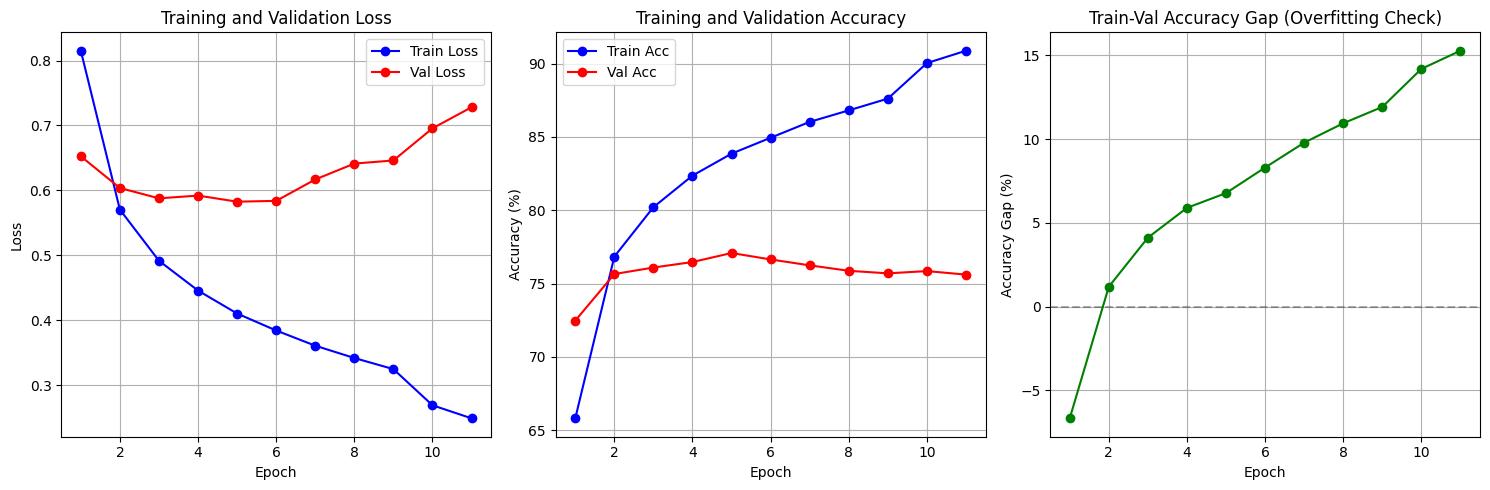


Training Summary
Total epochs completed: 11
Best validation loss: 0.5826 (Epoch 5)
Best validation accuracy: 77.08% (Epoch 5)
Final train accuracy: 90.88%
Final val accuracy: 75.61%
Final train-val gap: 15.27%


In [ ]:
#Plot training curves
plt.figure(figsize=(15, 5))

#Loss plot
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

#Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-o', label='Train Acc')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

#Train-Val Gap to see overfitting (the larger the gap, the more overfitting)
plt.subplot(1, 3, 3)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
plt.plot(range(1, len(gap) + 1), gap, 'g-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.title('Train-Val Accuracy Gap (Overfitting Check)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

# Test Eval & Confusion Matrix

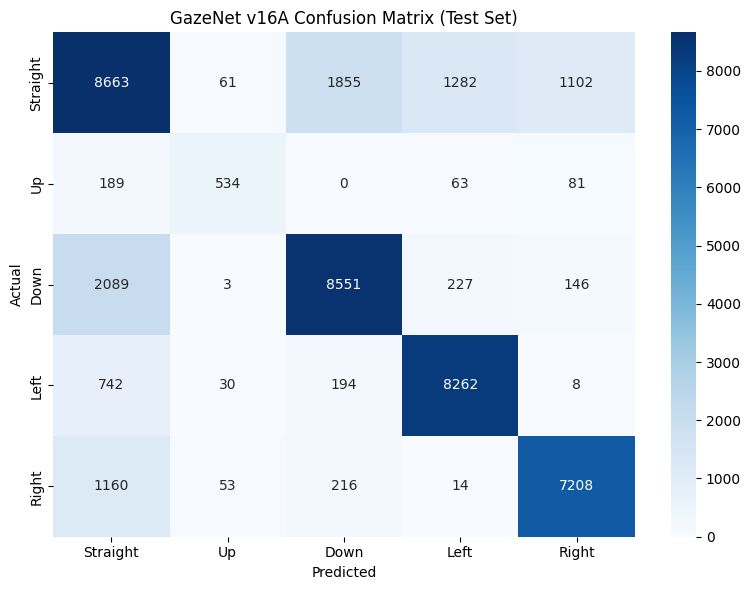


Test Set Performance
              precision    recall  f1-score   support

    Straight       0.67      0.67      0.67     12963
          Up       0.78      0.62      0.69       867
        Down       0.79      0.78      0.78     11016
        Left       0.84      0.89      0.87      9236
       Right       0.84      0.83      0.84      8651

    accuracy                           0.78     42733
   macro avg       0.79      0.76      0.77     42733
weighted avg       0.78      0.78      0.78     42733



In [ ]:
#Load best model

#primary drive-
model.load_state_dict(torch.load('/content/drive/MyDrive/checkpoints/best_gazenet_model_v16A.pth'))


model.eval()

#Collect predictions and labels
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye = batch['left_eye'].to(device)
        right_eye = batch['right_eye'].to(device)
        face = batch['face'].to(device)
        labels = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#Create confusion matrix
label_names = ['Straight', 'Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('GazeNet v16A Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

#Print classification report
print("\n" + "="*50)
print("Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

# For Katya

In [ ]:
#Model input/output interface
model.eval()

test_batch = next(iter(test_loader))

left_eye = test_batch['left_eye'].to(device)
right_eye = test_batch['right_eye'].to(device)
face = test_batch['face'].to(device)

with torch.no_grad():
    outputs = model(left_eye, right_eye, face)

print("MODEL INTERFACE")
print("="*50)

print(f"\nInputs (3 image tensors):")
print(f"  left_eye:  {left_eye.shape}  (batch, channels, height, width)")
print(f"  right_eye: {right_eye.shape}  (batch, channels, height, width)")
print(f"  face:      {face.shape}  (batch, channels, height, width)")

print(f"\nOutput:")
print(f"  shape: {outputs.shape}  (batch, 5 class scores)")
print(f"  classes: [0=Straight, 1=Up, 2=Down, 3=Left, 4=Right]")

print(f"\nSample output (first sample):")
print(f"  Raw logits:    {outputs[0].cpu().numpy()}")
probs = torch.softmax(outputs[0], dim=0)
print(f"  Probabilities: {probs.cpu().numpy()}")
print(f"  Prediction:    {['Straight','Up','Down','Left','Right'][torch.argmax(outputs[0]).item()]}")
print(f"  Confidence:    {probs.max().item():.1%}")

print(f"\nPreprocessing required:")
print(f"  Eyes: resize to 48x48, normalize with mean=0.5, std=0.5")
print(f"  Face: 112x112 (already sized), normalize with mean=0.5, std=0.5")

MODEL INTERFACE

Inputs (3 image tensors):
  left_eye:  torch.Size([32, 3, 48, 48])  (batch, channels, height, width)
  right_eye: torch.Size([32, 3, 48, 48])  (batch, channels, height, width)
  face:      torch.Size([32, 3, 112, 112])  (batch, channels, height, width)

Output:
  shape: torch.Size([32, 5])  (batch, 5 class scores)
  classes: [0=Straight, 1=Up, 2=Down, 3=Left, 4=Right]

Sample output (first sample):
  Raw logits:    [  2.6589322 -15.019601    5.394843   -2.8395326  -6.8615174]
  Probabilities: [6.0871854e-02 1.2785778e-09 9.3887448e-01 2.4915152e-04 4.4641379e-06]
  Prediction:    Down
  Confidence:    93.9%

Preprocessing required:
  Eyes: resize to 48x48, normalize with mean=0.5, std=0.5
  Face: 112x112 (already sized), normalize with mean=0.5, std=0.5
